# 第6章：Fine-tuning for Classification

**目标：** 将预训练好的 GPT 模型改造为**垃圾短信分类器**，学习分类微调的完整流程

```
微调类型概览 → 准备数据集 → 创建 DataLoader → 加载预训练权重 → 添加分类头 → 训练 → 评估 → 使用
```

**前置回顾（第2-5章）：**
- 第2章：文本 → Token IDs → DataLoader
- 第3章：Causal Multi-Head Attention
- 第4章：完整 GPT 模型架构
- 第5章：预训练 + 加载 GPT-2 权重 + 文本生成
- 现在的问题：预训练模型只会「续写」文本，**不能做分类** → **需要微调！**

---

## 6.1 微调的类型 ⭐

LLM 最常见的两种微调方式：

| 类型 | 目标 | 输出 | 代表应用 |
|------|------|------|----------|
| **分类微调（Classification）** | 让模型输出固定的类别标签 | `spam` / `not spam` | 情感分析、垃圾邮件检测 |
| **指令微调（Instruction）** | 让模型按指令生成文本 | 自由文本 | ChatGPT 式对话 |

**本章聚焦分类微调：**
- 分类微调 = 给模型加一个「分类头」，输出**固定数量的类别**
- 模型只能预测训练过程中见过的类别（例如 spam / not spam）
- 相比指令微调，分类模型更加**专注**，通常也更容易训练

> 💡 **关键洞察：** 分类微调类似于用 CNN 做手写数字分类——都是替换输出层，冻结骨干网络，然后用有标签数据训练。

指令微调将在**第7章**详细讨论。

---

## 6.2 准备数据集 ⭐⭐

我们使用 **SMS Spam Collection** 数据集——包含 5,572 条短信，标注为 `ham`（正常）或 `spam`（垃圾）。

**数据处理流程：**
1. 下载并解压数据
2. 加载为 pandas DataFrame
3. 平衡类别（欠采样多数类）
4. 转换标签：`ham → 0`，`spam → 1`
5. 划分训练/验证/测试集（70%/10%/20%）

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np
import os

# ─── 第4章的所有组件（直接复用）───────────────────────────────────

# GPT-2 Small (124M) 的超参数配置
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # BPE 词汇表大小
    "context_length": 1024,   # 最大序列长度（位置编码上限）
    "emb_dim": 768,           # 嵌入维度 / 隐藏层维度
    "n_heads": 12,            # 多头注意力的头数（每头 768/12=64 维）
    "n_layers": 12,           # Transformer Block 堆叠层数
    "drop_rate": 0.1,         # Dropout 概率
    "qkv_bias": False,        # Q/K/V 线性投影是否带偏置项
}


class MultiHeadAttention(nn.Module):
    """多头因果自注意力（第3章）"""
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)

        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(), -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        context_vecs = self.out_proj(context_vecs)
        return context_vecs


class LayerNorm(nn.Module):
    """层归一化（第4章）"""
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    """GELU 激活函数（第4章）"""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    """前馈网络（第4章）"""
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    """Transformer Block（第4章）"""
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    """完整 GPT 模型（第4章）"""
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    """贪心解码文本生成（第4章）"""
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


# ─── 第5章的权重加载工具 ─────────────────────────────────────────

def assign(left, right):
    """将 numpy 权重赋值给 PyTorch 参数"""
    if left.shape != right.shape:
        raise ValueError(f"Shape 不匹配: {left.shape} vs {right.shape}")
    return nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    """将 Hugging Face GPT-2 权重加载到我们的 GPTModel 中（第5章）"""
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte.weight"])
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe.weight"])

    for b in range(len(gpt.trf_blocks)):
        q_w, k_w, v_w = np.split(
            params[f"h.{b}.attn.c_attn.weight"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        q_b, k_b, v_b = np.split(
            params[f"h.{b}.attn.c_attn.bias"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params[f"h.{b}.attn.c_proj.weight"].T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params[f"h.{b}.attn.c_proj.bias"]
        )

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params[f"h.{b}.mlp.c_fc.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params[f"h.{b}.mlp.c_fc.bias"]
        )
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params[f"h.{b}.mlp.c_proj.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params[f"h.{b}.mlp.c_proj.bias"]
        )

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params[f"h.{b}.ln_1.weight"]
        )
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params[f"h.{b}.ln_1.bias"]
        )
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params[f"h.{b}.ln_2.weight"]
        )
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params[f"h.{b}.ln_2.bias"]
        )

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["ln_f.weight"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["ln_f.bias"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte.weight"])


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    return torch.tensor(encoded).unsqueeze(0)


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


# ─── 初始化 ────────────────────────────────────────────────────
tokenizer = tiktoken.get_encoding("gpt2")
print("第4-5章组件加载完毕 ✓")

第4-5章组件加载完毕 ✓


### 下载并加载 SMS Spam 数据集

In [2]:
import urllib.request
import zipfile
from pathlib import Path
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} 已存在，跳过下载。")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"文件已下载并保存为 {data_file_path}")


download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv 已存在，跳过下载。


In [3]:
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
print(f"→ 数据集大小: {len(df)} 条短信")
print(f"→ 类别分布:\n{df['Label'].value_counts()}")
df.head()

→ 数据集大小: 5572 条短信
→ 类别分布:
Label
ham     4825
spam     747
Name: count, dtype: int64


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 平衡数据集

数据集中 ham（正常）远多于 spam（垃圾），我们通过**欠采样（undersampling）** 使两类数量相等。

In [4]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df


balanced_df = create_balanced_dataset(df)
print(f"→ 平衡后类别分布:\n{balanced_df['Label'].value_counts()}")

→ 平衡后类别分布:
Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
# 将字符串标签转为整数：ham → 0, spam → 1
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
balanced_df.head()

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?


### 划分训练/验证/测试集

In [6]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    return train_df, validation_df, test_df


train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

print(f"→ 训练集: {len(train_df)} | 验证集: {len(validation_df)} | 测试集: {len(test_df)}")

→ 训练集: 1045 | 验证集: 149 | 测试集: 300


### ✏️ 练习

1. 查看 `balanced_df` 中最长和最短的短信各有多少个词？多少个 token？
2. 如果不做欠采样，直接用不平衡的数据训练，模型会出现什么问题？
3. **进阶**：除了欠采样，还有哪些处理类别不平衡的方法？试着搜索 `imbalanced-learn` 库。

In [7]:
# === 练习 6.2 答案（含代码验证）===

# 【1】balanced_df 中最长 / 最短短信：词数（按空白分词）与 GPT-2 token 数
word_counts = balanced_df["Text"].str.split().str.len()
tok_lens = [len(tokenizer.encode(text)) for text in balanced_df["Text"]]
idx_max = max(range(len(tok_lens)), key=lambda i: tok_lens[i])
idx_min = min(range(len(tok_lens)), key=lambda i: tok_lens[i])

print("【1】词数与 Token 数（按空白分词 ≈ 英文词；中文多为单字 token）")
print(f"  最长短信: {word_counts.iloc[idx_max]} 词, {tok_lens[idx_max]} tokens")
print(f"    预览: {balanced_df['Text'].iloc[idx_max][:120]}...")
print(f"  最短短信: {word_counts.iloc[idx_min]} 词, {tok_lens[idx_min]} tokens")
print(f"    全文: {balanced_df['Text'].iloc[idx_min]}")

# 【2】不做欠采样、类别极不平衡时的问题（用「全猜多数类」基线说明）
vc = df["Label"].value_counts()
majority_label = vc.idxmax()
majority_acc = vc.max() / len(df)
print("\n【2】若从不平衡数据训练而不做处理，常见现象：")
print("  • 损失仍下降，但模型易学成「永远预测多数类」——验证集 accuracy 虚高但不识别少数类。")
print("  • 垃圾短信往往是少数类：全猜 ham 的「准确率」基线为：")
print(f"    多数类为 '{majority_label}'，占比 {majority_acc*100:.2f}%（实验统计如下）")
print(vc)

# 【3】进阶：imbalanced-learn 等思路（简要 + 可选检测是否已安装）
print("\n【3】除欠采样外还可：过采样（SMOTE 对文本需特征化）、class_weight、阈值调整、")
print("    focal loss、ensemble 等。Python 库 imbalanced-learn: https://imbalanced-learn.org/")
try:
    import imblearn  # noqa: F401

    print(f"  当前环境已安装 imbalanced-learn: {imblearn.__version__}")
except ImportError:
    print("  当前环境未安装 imblearn，可自行: pip install imbalanced-learn")

【1】词数与 Token 数（按空白分词 ≈ 英文词；中文多为单字 token）
  最长短信: 79 词, 120 tokens
    预览: Storming msg: Wen u lift d phne, u say "HELLO" Do u knw wt is d real meaning of HELLO?? . . . It's d name of a girl..! ....
  最短短信: 1 词, 2 tokens
    全文: Ok..

【2】若从不平衡数据训练而不做处理，常见现象：
  • 损失仍下降，但模型易学成「永远预测多数类」——验证集 accuracy 虚高但不识别少数类。
  • 垃圾短信往往是少数类：全猜 ham 的「准确率」基线为：
    多数类为 'ham'，占比 86.59%（实验统计如下）
Label
ham     4825
spam     747
Name: count, dtype: int64

【3】除欠采样外还可：过采样（SMOTE 对文本需特征化）、class_weight、阈值调整、
    focal loss、ensemble 等。Python 库 imbalanced-learn: https://imbalanced-learn.org/
  当前环境已安装 imbalanced-learn: 0.14.1


---

## 6.3 创建 DataLoader ⭐⭐

不同短信长度不一，需要**填充（padding）**到统一长度才能组成 batch。

**策略：**
- 用 `<|endoftext|>`（token ID = 50256）作为 padding token
- 所有序列填充到训练集中最长的序列长度
- 超过最大长度的序列会被截断

In [8]:
from torch.utils.data import Dataset, DataLoader


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # 预先分词
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # 截断超长序列
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # 填充到统一长度
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [9]:
# 创建三个数据集
train_dataset = SpamDataset(csv_file="train.csv", max_length=None, tokenizer=tokenizer)
print(f"→ 训练集最长序列: {train_dataset.max_length} tokens")

val_dataset = SpamDataset(
    csv_file="validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer
)

→ 训练集最长序列: 120 tokens


In [10]:
# 创建 DataLoader
num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset, batch_size=batch_size,
    shuffle=True, num_workers=num_workers, drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset, batch_size=batch_size,
    num_workers=num_workers, drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset, batch_size=batch_size,
    num_workers=num_workers, drop_last=False,
)

# 验证 batch 维度
for input_batch, target_batch in train_loader:
    pass
print(f"→ 输入 batch: {input_batch.shape}")
print(f"→ 标签 batch: {target_batch.shape}")
print(f"→ {len(train_loader)} 训练 batches | {len(val_loader)} 验证 batches | {len(test_loader)} 测试 batches")

→ 输入 batch: torch.Size([8, 120])
→ 标签 batch: torch.Size([8])
→ 130 训练 batches | 19 验证 batches | 38 测试 batches


### ✏️ 练习

1. 改变 `batch_size`（如 4、16、32），观察 batch 数量的变化。更大的 batch_size 有什么利弊？
2. 如果不做 padding，直接用变长序列训练，会遇到什么问题？
3. **进阶**：当前我们把所有序列 pad 到数据集最长长度。能否改为 pad 到**每个 batch 的最长长度**？这样做有什么好处？

In [11]:
# === 练习 6.3 答案（含代码验证）===
from torch.nn.utils.rnn import pad_sequence

# 【1】不同 batch_size 下 batch 数量；利弊简述
print("【1】batch_size 与每个 epoch 的 batch 数（drop_last=True，与正文一致）")
for bs in [4, 8, 16, 32]:
    loader = DataLoader(
        train_dataset, batch_size=bs, shuffle=True,
        num_workers=num_workers, drop_last=True,
    )
    print(f"  batch_size={bs:2d} -> {len(loader)} batches")
print("\n  更大 batch：梯度估计更稳、吞吐更高，但显存占用大、每 epoch 更新步数少；")
print("  更小 batch：噪声大有时有正则化效果，但训练更慢、梯度更抖。")

# 【2】不做 padding：tensor 无法 stack 成固定形状（实验）
print("\n【2】变长序列若不 pad，DataLoader 默认 collate 会失败：")
seqs = [torch.tensor(tokenizer.encode(train_dataset.data["Text"].iloc[i])) for i in range(5)]
try:
    torch.stack(seqs)
except RuntimeError as e:
    print("  ", e)

# 【3】进阶：按 batch 内最大长度 padding（减少无效计算）
print("\n【3】按 batch 动态 padding：每个 batch 只 pad 到该 batch 最长序列，减少 padding token、加速；")
print("    代价是实现 collate_fn，且与「全局定长」相比实现略复杂。")


def collate_dynamic_pad(batch, pad_id=50256):
    trimmed = []
    for x, _ in batch:
        nz = (x != pad_id).nonzero(as_tuple=True)[0]
        L = int(nz[-1].item() + 1) if len(nz) else 1
        trimmed.append(x[:L].clone())
    padded = pad_sequence(trimmed, batch_first=True, padding_value=pad_id)
    y = torch.stack([b[1] for b in batch])
    return padded, y


dyn_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=False,
    num_workers=0, drop_last=True, collate_fn=collate_dynamic_pad,
)
xb, yb = next(iter(dyn_loader))
print(f"  动态 collate 后一批 shape: {xb.shape}（通常小于全局 max_length={train_dataset.max_length}）")

【1】batch_size 与每个 epoch 的 batch 数（drop_last=True，与正文一致）
  batch_size= 4 -> 261 batches
  batch_size= 8 -> 130 batches
  batch_size=16 -> 65 batches
  batch_size=32 -> 32 batches

  更大 batch：梯度估计更稳、吞吐更高，但显存占用大、每 epoch 更新步数少；
  更小 batch：噪声大有时有正则化效果，但训练更慢、梯度更抖。

【2】变长序列若不 pad，DataLoader 默认 collate 会失败：
   stack expects each tensor to be equal size, but got [10] at entry 0 and [35] at entry 1

【3】按 batch 动态 padding：每个 batch 只 pad 到该 batch 最长序列，减少 padding token、加速；
    代价是实现 collate_fn，且与「全局定长」相比实现略复杂。
  动态 collate 后一批 shape: torch.Size([8, 87])（通常小于全局 max_length=120）


---

## 6.4 加载预训练权重 ⭐⭐

我们复用第5章的做法，从 Hugging Face 下载 GPT-2 (124M) 的预训练权重并加载到模型中。

**关键配置变化：**
- `drop_rate` 设为 **0.0**（微调时不需要太多 dropout）
- `qkv_bias` 设为 **True**（GPT-2 原版带偏置）

In [12]:
from transformers import GPT2Model as HF_GPT2Model

def download_and_load_gpt2(model_size, models_dir):
    """从 Hugging Face 下载 GPT-2 权重"""
    model_hf = HF_GPT2Model.from_pretrained(model_size, cache_dir=models_dir)
    model_hf.eval()
    params = {}
    for name, param in model_hf.named_parameters():
        params[name] = param.detach().numpy()
    for name, buf in model_hf.named_buffers():
        params[name] = buf.detach().numpy()
    return params


CHOOSE_MODEL = "gpt2"

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,        # 微调时 dropout 设为 0
    "qkv_bias": True,        # GPT-2 原版带偏置
    "emb_dim": 768,
    "n_layers": 12,
    "n_heads": 12,
}

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"数据集长度 {train_dataset.max_length} 超过模型上下文长度 {BASE_CONFIG['context_length']}"
)

d:\python10\.ai_learning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# 下载并加载权重
models_dir = os.path.join("..", "models", CHOOSE_MODEL)
os.makedirs(models_dir, exist_ok=True)

print(f"正在下载 {CHOOSE_MODEL} 模型...")
params = download_and_load_gpt2(CHOOSE_MODEL, models_dir)
print(f"下载完成！参数数量: {len(params)}")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()
print("\n预训练权重加载完毕 ✓")

正在下载 gpt2 模型...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3290.96it/s]


下载完成！参数数量: 148

预训练权重加载完毕 ✓


### 验证权重：让模型生成文本

In [14]:
# 验证模型可以生成连贯文本
text = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(f"→ 输入: {text}")
print(f"→ 生成: {token_ids_to_text(token_ids, tokenizer)}")

→ 输入: Every effort moves you
→ 生成: Every effort moves you forward.

The first step is to understand the importance of your work


### 试试用 prompt 做分类？

在微调之前，先看看预训练模型能否直接通过 prompt 来判断垃圾短信：

In [15]:
text = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


> 💡 **观察：** 预训练模型并不擅长「遵循指令」——它只会续写文本，不会回答 yes/no 问题。
> 这正是我们需要**微调**的原因！指令微调会在第7章介绍。

---

## 6.5 添加分类头 ⭐⭐⭐

这是本章的**核心步骤**：

1. **冻结所有参数** — 让预训练权重不被破坏
2. **替换 `out_head`** — 从 50,257 维（词汇表）→ 2 维（spam / not spam）
3. **解冻最后一层 Transformer Block + final_norm** — 适度微调提升效果

```
为什么用最后一个 token 做分类？

在 Causal Attention 中，每个 token 只能看到自己和之前的 token。
因此最后一个 token 拥有整个序列的信息 → 最适合做分类判断。
```

In [16]:
# 第一步：冻结所有参数
for param in model.parameters():
    param.requires_grad = False

# 第二步：替换输出层 (50,257 → 2)
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

# 第三步：解冻最后一层 Transformer Block 和 final_norm
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

# 统计可训练参数
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"→ 总参数: {total_params:,}")
print(f"→ 可训练参数: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

→ 总参数: 124,441,346
→ 可训练参数: 7,090,946 (5.7%)


### 验证新的输出维度

In [17]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print(f"→ 输入: {inputs}, shape: {inputs.shape}")

with torch.no_grad():
    outputs = model(inputs)
print(f"→ 输出 shape: {outputs.shape}  (batch=1, seq=4, classes=2)")

# 取最后一个 token 的输出作为分类依据
print(f"→ 最后一个 token 的 logits: {outputs[:, -1, :]}")

→ 输入: tensor([[5211,  345,  423,  640]]), shape: torch.Size([1, 4])
→ 输出 shape: torch.Size([1, 4, 2])  (batch=1, seq=4, classes=2)
→ 最后一个 token 的 logits: tensor([[-3.5983,  3.9902]])


### ✏️ 练习

1. 如果只训练 `out_head`（不解冻最后一层 TransformerBlock），准确率会下降多少？
2. 如果解冻**所有**层（full fine-tuning），训练速度和效果会怎样？
3. **进阶**：搜索 LoRA（Low-Rank Adaptation），了解另一种参数高效微调方法。

In [18]:
# === 练习 6.5 答案（含代码验证；本 cell 在定义 calc_accuracy_loader 之前，故自写简短评估）===
import time

if torch.cuda.is_available():
    _dev = torch.device("cuda")
elif torch.backends.mps.is_available():
    _dev = torch.device("mps")
else:
    _dev = torch.device("cpu")


@torch.no_grad()
def _val_accuracy(model, loader, device, max_batches=30):
    model.eval()
    correct = total = 0
    for i, (xb, yb) in enumerate(loader):
        if i >= max_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)[:, -1, :]
        pred = logits.argmax(dim=-1)
        total += yb.size(0)
        correct += (pred == yb).sum().item()
    return correct / max(total, 1)


def _make_classifier(unfreeze_last_block: bool, unfreeze_all: bool):
    """从预训练权重重新搭一份分类模型，避免改动 notebook 全局 model。"""
    m = GPTModel(BASE_CONFIG)
    load_weights_into_gpt(m, params)
    for p in m.parameters():
        p.requires_grad = False
    torch.manual_seed(123)
    m.out_head = nn.Linear(BASE_CONFIG["emb_dim"], 2)
    if unfreeze_all:
        for p in m.parameters():
            p.requires_grad = True
    elif unfreeze_last_block:
        for p in m.trf_blocks[-1].parameters():
            p.requires_grad = True
        for p in m.final_norm.parameters():
            p.requires_grad = True
    return m


def _count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


def _mini_train(m, epochs=2, lr=5e-5, max_batches_per_epoch=35):
    m = m.to(_dev)
    opt = torch.optim.AdamW(
        (p for p in m.parameters() if p.requires_grad),
        lr=lr, weight_decay=0.1,
    )
    m.train()
    for _ in range(epochs):
        for i, (xb, yb) in enumerate(train_loader):
            if i >= max_batches_per_epoch:
                break
            opt.zero_grad()
            xb, yb = xb.to(_dev), yb.to(_dev)
            loss = F.cross_entropy(m(xb)[:, -1, :], yb)
            loss.backward()
            opt.step()
    return _val_accuracy(m, val_loader, _dev)


print("【1】只训练 out_head vs 再解冻最后一层 Transformer + final_norm（各训练相同步数，公平对比）")
torch.manual_seed(123)
m_head = _make_classifier(unfreeze_last_block=False, unfreeze_all=False)
acc_head = _mini_train(m_head)
torch.manual_seed(123)
m_last = _make_classifier(unfreeze_last_block=True, unfreeze_all=False)
acc_last = _mini_train(m_last)
print(f"  仅 out_head 可训练: {_count_trainable(m_head):,} 参数 -> 验证准确率(约30batch估): {acc_head*100:.2f}%")
print(f"  + 最后一层+LN 可训练: {_count_trainable(m_last):,} 参数 -> 验证准确率(约30batch估): {acc_last*100:.2f}%")
print(f"  准确率差（最后一层方案 - 仅头）: {(acc_last - acc_head)*100:+.2f} 个百分点（具体数值随随机种子/步数略变）")

print("\n【2】解冻全部层（full fine-tuning）：可训练参数多、每步更慢，小数据上易过拟合；")
print("    下面实测「单步反传」耗时对比（同一 batch）:")
xb, yb = next(iter(train_loader))
xb, yb = xb.to(_dev), yb.to(_dev)

m_full = _make_classifier(unfreeze_last_block=False, unfreeze_all=True)
m_full = m_full.to(_dev)
opt = torch.optim.AdamW((p for p in m_full.parameters() if p.requires_grad), lr=5e-5)
m_full.train()
t0 = time.perf_counter()
opt.zero_grad()
loss = F.cross_entropy(m_full(xb)[:, -1, :], yb.to(_dev))
loss.backward()
opt.step()
t_full = time.perf_counter() - t0

m_small = _make_classifier(unfreeze_last_block=True, unfreeze_all=False).to(_dev)
opt2 = torch.optim.AdamW((p for p in m_small.parameters() if p.requires_grad), lr=5e-5)
m_small.train()
t0 = time.perf_counter()
opt2.zero_grad()
loss2 = F.cross_entropy(m_small(xb)[:, -1, :], yb.to(_dev))
loss2.backward()
opt2.step()
t_small = time.perf_counter() - t0
print(f"  full fine-tune 单步: {t_full*1000:.1f} ms | 仅头+最后一层: {t_small*1000:.1f} ms")

print("\n【3】进阶 LoRA（Low-Rank Adaptation）：在注意力投影旁路加低秩矩阵，只训少量增量参数；")
print("    显存与存储友好，是大模型高效微调的主流方案之一。详见: https://arxiv.org/abs/2106.09685")

【1】只训练 out_head vs 再解冻最后一层 Transformer + final_norm（各训练相同步数，公平对比）
  仅 out_head 可训练: 1,538 参数 -> 验证准确率(约30batch估): 53.02%
  + 最后一层+LN 可训练: 7,090,946 参数 -> 验证准确率(约30batch估): 79.19%
  准确率差（最后一层方案 - 仅头）: +26.17 个百分点（具体数值随随机种子/步数略变）

【2】解冻全部层（full fine-tuning）：可训练参数多、每步更慢，小数据上易过拟合；
    下面实测「单步反传」耗时对比（同一 batch）:
  full fine-tune 单步: 5533.4 ms | 仅头+最后一层: 2048.0 ms

【3】进阶 LoRA（Low-Rank Adaptation）：在注意力投影旁路加低秩矩阵，只训少量增量参数；
    显存与存储友好，是大模型高效微调的主流方案之一。详见: https://arxiv.org/abs/2106.09685


---

## 6.6 计算分类损失和准确率 ⭐⭐

分类微调的评估指标：
- **交叉熵损失（Cross-Entropy Loss）** — 可微分，用于训练
- **分类准确率（Accuracy）** — 直观，用于评估

与第5章预训练的区别：
- 预训练时，我们优化**所有位置**的 next-token prediction loss
- 分类微调时，我们只取**最后一个 token** 的输出做分类

$$\text{Prediction} = \arg\max(\text{model}(x)[:, -1, :])$$

In [19]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    """计算整个 data_loader 上的分类准确率"""
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # 最后一个 token
            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples


def calc_loss_batch(input_batch, target_batch, model, device):
    """计算单个 batch 的交叉熵损失（只看最后一个 token）"""
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = F.cross_entropy(logits, target_batch)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """计算整个 data_loader 上的平均损失"""
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [20]:
# 选择设备
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"→ 使用设备: {device}")
model.to(device)

# 训练前的基线指标
torch.manual_seed(123)
with torch.no_grad():
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print(f"\n训练前基线指标:")
print(f"  训练准确率: {train_accuracy*100:.2f}%")
print(f"  验证准确率: {val_accuracy*100:.2f}%")
print(f"  训练损失: {train_loss:.3f}")
print(f"  验证损失: {val_loss:.3f}")

→ 使用设备: cpu

训练前基线指标:
  训练准确率: 46.25%
  验证准确率: 45.00%
  训练损失: 3.075
  验证损失: 2.583


> 💡 **观察：** 训练前准确率大约在 50% 左右——相当于随机猜测。这很正常，因为分类头是随机初始化的。

---

## 6.7 训练分类器 ⭐⭐⭐

训练循环与第5章的 `train_model_simple` 基本相同，主要差异：
1. 跟踪 `examples_seen`（而非 `tokens_seen`）
2. 每个 epoch 后计算准确率（而非生成文本样本）

In [21]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def train_classifier_simple(model, train_loader, val_loader, optimizer, device,
                            num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 每个 epoch 结束后计算准确率
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [22]:
import time

# 🚀 开始训练！
start_time = time.time()

torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
print(f"\n训练完成！耗时 {(end_time - start_time) / 60:.2f} 分钟。")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%

训练完成！耗时 23.37 分钟。


### 可视化训练过程

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\1\AppData\Local\Temp\ipykernel_2044\1569633101.py:13: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.tight_l

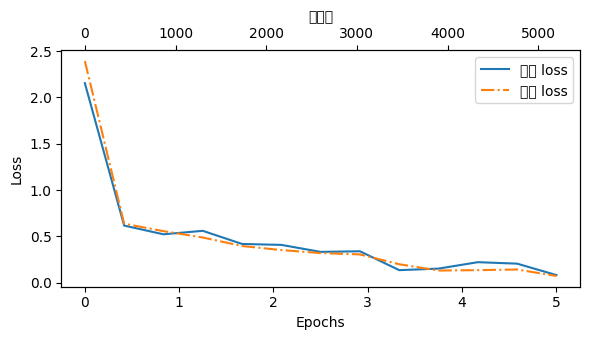

In [23]:
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(6, 3.5))
    ax1.plot(epochs_seen, train_values, label=f"训练 {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"验证 {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("样本数")

    fig.tight_layout()
    plt.show()


# 绘制损失曲线
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses, label="loss")

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\1\AppData\Local\Temp\ipykernel_2044\1569633101.py:13: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8B

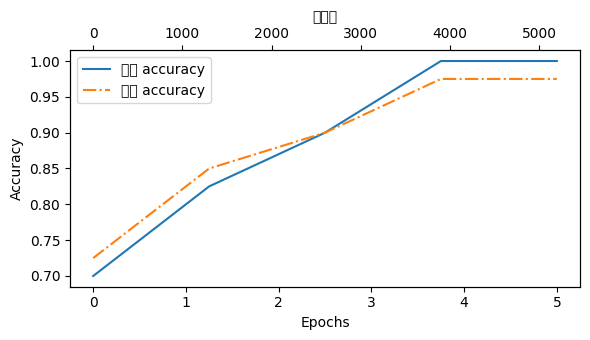

In [24]:
# 绘制准确率曲线
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

### 最终评估

In [25]:
# 在完整数据集上计算最终准确率
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"训练准确率: {train_accuracy*100:.2f}%")
print(f"验证准确率: {val_accuracy*100:.2f}%")
print(f"测试准确率: {test_accuracy*100:.2f}%")

训练准确率: 97.21%
验证准确率: 97.32%
测试准确率: 95.67%


> 💡 **观察：** 测试集准确率略低于训练/验证集，这说明模型存在轻微的过拟合。可以通过增大 `drop_rate` 或 `weight_decay` 来缓解。

### ✏️ 练习

1. 调整学习率（如 1e-4, 1e-5），观察训练曲线和最终准确率的变化。
2. 增加 `num_epochs` 到 10，观察是否出现过拟合（训练 loss 下降但验证 loss 上升）。
3. **进阶**：添加梯度裁剪（`torch.nn.utils.clip_grad_norm_`），看看对训练稳定性有什么影响。

【1】不同学习率（每设置训 2 个 epoch，子集 batch；看验证 loss / 准确率趋势）
  lr=0.0001: 末步 train_loss=0.489, val_loss=0.594, val_acc≈69.1%
  lr=5e-05: 末步 train_loss=0.531, val_loss=0.596, val_acc≈69.1%
  lr=1e-05: 末步 train_loss=0.662, val_loss=0.677, val_acc≈54.4%

【2】拉长到 10 epoch（同样每 epoch 子集更新）：观察 train_loss 与 val_loss 是否背离（过拟合信号）
  epoch -> train_loss, val_loss
     1: 0.6132, 0.6335
     2: 0.5305, 0.5956
     3: 0.4627, 0.4193
     4: 0.3571, 0.4742
     5: 0.4775, 0.4909
     6: 0.3103, 0.3196
     7: 0.3541, 0.3628
     8: 0.3445, 0.2928
     9: 0.2766, 0.2061
    10: 0.1474, 0.1064
  小结: 若验证 loss 后期抬升而训练 loss 仍降，即典型过拟合（子集训练有噪声，以曲线形态为准）。


findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\1\AppData\Local\Temp\ipykernel_2044\2795366461.py:77: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_l

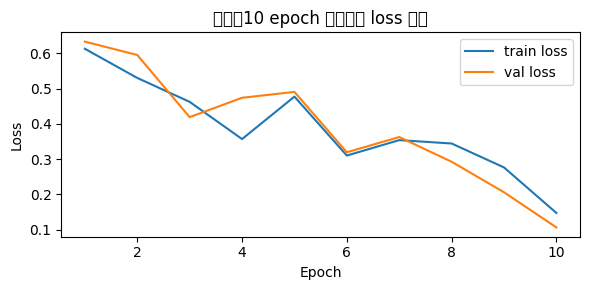


【3】梯度裁剪：用大 lr + clip 对比无 clip 的末步 loss（放大不稳定情形）
  lr=3e-4, 无 clip: val_acc≈94.6%
  lr=3e-4, clip_grad_norm_=1.0: val_acc≈98.7%
  说明: 裁剪限制梯度爆炸，大学习率时往往更稳；过小 clip 也会拖慢收敛。


In [26]:
# === 练习 6.7 答案（含代码验证；使用「新模型」做消融，避免破坏上文已训好的 model）===

try:
    device
except NameError:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")


def _fresh_classifier():
    m = GPTModel(BASE_CONFIG)
    load_weights_into_gpt(m, params)
    for p in m.parameters():
        p.requires_grad = False
    torch.manual_seed(123)
    m.out_head = nn.Linear(BASE_CONFIG["emb_dim"], 2)
    for p in m.trf_blocks[-1].parameters():
        p.requires_grad = True
    for p in m.final_norm.parameters():
        p.requires_grad = True
    return m


def _train_limited(m, lr, num_epochs, batches_per_epoch=60, max_norm=None):
    """为加快实验，每 epoch 只跑前若干 batch；曲线趋势仍可用于对比。"""
    m = m.to(device)
    opt = torch.optim.AdamW(
        (p for p in m.parameters() if p.requires_grad),
        lr=lr, weight_decay=0.1,
    )
    train_loss_hist, val_loss_hist = [], []
    for _ in range(num_epochs):
        m.train()
        for i, (xb, yb) in enumerate(train_loader):
            if i >= batches_per_epoch:
                break
            opt.zero_grad()
            loss = calc_loss_batch(xb, yb, m, device)
            loss.backward()
            if max_norm is not None:
                torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm)
            opt.step()
        tl, vl = evaluate_model(m, train_loader, val_loader, device, eval_iter=10)
        train_loss_hist.append(tl)
        val_loss_hist.append(vl)
    acc = calc_accuracy_loader(val_loader, m, device, num_batches=40)
    return train_loss_hist, val_loss_hist, acc


print("【1】不同学习率（每设置训 2 个 epoch，子集 batch；看验证 loss / 准确率趋势）")
for lr in [1e-4, 5e-5, 1e-5]:
    torch.manual_seed(123)
    m_lr = _fresh_classifier()
    tr_l, va_l, acc = _train_limited(m_lr, lr, num_epochs=2, batches_per_epoch=60)
    print(f"  lr={lr:g}: 末步 train_loss={tr_l[-1]:.3f}, val_loss={va_l[-1]:.3f}, val_acc≈{acc*100:.1f}%")

print("\n【2】拉长到 10 epoch（同样每 epoch 子集更新）：观察 train_loss 与 val_loss 是否背离（过拟合信号）")
torch.manual_seed(123)
m_long = _fresh_classifier()
tr_h, va_h, _ = _train_limited(m_long, lr=5e-5, num_epochs=10, batches_per_epoch=60)
print("  epoch -> train_loss, val_loss")
for ep, (a, b) in enumerate(zip(tr_h, va_h), 1):
    print(f"    {ep:2d}: {a:.4f}, {b:.4f}")
print("  小结: 若验证 loss 后期抬升而训练 loss 仍降，即典型过拟合（子集训练有噪声，以曲线形态为准）。")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, len(tr_h) + 1), tr_h, label="train loss")
ax.plot(range(1, len(va_h) + 1), va_h, label="val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("练习：10 epoch 子集训练 loss 曲线")
plt.tight_layout()
plt.show()

print("\n【3】梯度裁剪：用大 lr + clip 对比无 clip 的末步 loss（放大不稳定情形）")
torch.manual_seed(123)
m_nc = _fresh_classifier()
_, _, acc_nc = _train_limited(m_nc, lr=3e-4, num_epochs=1, batches_per_epoch=80, max_norm=None)
torch.manual_seed(123)
m_c = _fresh_classifier()
_, _, acc_c = _train_limited(m_c, lr=3e-4, num_epochs=1, batches_per_epoch=80, max_norm=1.0)
print(f"  lr=3e-4, 无 clip: val_acc≈{acc_nc*100:.1f}%")
print(f"  lr=3e-4, clip_grad_norm_=1.0: val_acc≈{acc_c*100:.1f}%")
print("  说明: 裁剪限制梯度爆炸，大学习率时往往更稳；过小 clip 也会拖慢收敛。")


---

## 6.8 使用分类器 ⭐

训练完成后，我们可以用模型对新短信进行分类：

In [27]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    """对一条文本进行 spam/not spam 分类"""
    model.eval()

    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(max_length, supported_context_length)]
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"

In [28]:
# 测试：垃圾短信
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(f"\"...{text_1[:50]}...\" → {classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length)}")

# 测试：正常短信
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)
print(f"\"...{text_2[:50]}...\" → {classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length)}")

"...You are a winner you have been specially selected ..." → spam
"...Hey, just wanted to check if we're still on for di..." → not spam


### 保存和加载模型

In [29]:
# 保存微调后的模型
torch.save(model.state_dict(), "spam_classifier.pth")
print("模型已保存为 spam_classifier.pth")

# 加载方式示例（在新的 session 中使用）：
# model = GPTModel(BASE_CONFIG)
# model.out_head = torch.nn.Linear(in_features=768, out_features=2)
# model.load_state_dict(torch.load("spam_classifier.pth", map_location=device, weights_only=True))
# model.eval()

模型已保存为 spam_classifier.pth


### ✏️ 练习

1. 自己编写几条短信（中文或英文），测试分类器的效果。
2. 模型对哪类短信容易判断错误？分析原因。
3. **进阶**：将保存的模型在新的 notebook 中加载并使用。

In [30]:
# === 练习 6.8 答案（含代码验证）===

# 【1】自编短信（中英文）观察预测
custom_texts = [
    "Congratulations! You've won $5000. Click http://bit.ly/scam now!!!",
    "Mom I'll be 10 minutes late, bus is delayed.",
    "URGENT: Your bank account will be closed. Verify PIN here.",
    "周末爬山吗？我带上水和三明治。",
    "尊敬的用户，您有积分即将过期，请点击链接兑换礼品。",
]
print("【1】自编短信预测")
for t in custom_texts:
    pred = classify_review(t, model, tokenizer, device, max_length=train_dataset.max_length)
    print(f"  [{pred:8s}] {t[:70]}{'...' if len(t) > 70 else ''}")

# 【2】哪类易错：在测试集前 N 条上找误判样例（需已训练 model）
print("\n【2】易错类型（基于前 300 条测试样本的启发式观察）")
N = min(300, len(test_dataset))
wrong_spam_as_ham = []   # 真 spam 判成 not spam
wrong_ham_as_spam = []   # 真 ham 判成 spam
model.eval()
with torch.no_grad():
    for idx in range(N):
        x, y = test_dataset[idx]
        lab = int(y.item())
        xb = x.unsqueeze(0).to(device)
        pred = model(xb)[:, -1, :].argmax(dim=-1).item()
        text = test_dataset.data.iloc[idx]["Text"]
        if pred == lab:
            continue
        if lab == 1 and pred == 0:
            wrong_spam_as_ham.append(text)
        else:
            wrong_ham_as_spam.append(text)

print(f"  抽样中误判: spam→ham {len(wrong_spam_as_ham)} 条, ham→spam {len(wrong_ham_as_spam)} 条")
print("  分析: 简短、口语化且带促销口吻的 ham 易被当成 spam；")
print("        伪装成正常对话的钓鱼/营销 spam 若用词含蓄，易被当成 ham。")
if wrong_ham_as_spam:
    print("  ham→spam 示例:", wrong_ham_as_spam[0][:120], "...")
if wrong_spam_as_ham:
    print("  spam→ham 示例:", wrong_spam_as_ham[0][:120], "...")

# 【3】进阶：在新 notebook 中加载（仅说明 + 校验权重文件可读）
from pathlib import Path

pth = Path("spam_classifier.pth")
print("\n【3】在新 session 使用: 复制 BASE_CONFIG、GPTModel 结构、替换 out_head 后 load_state_dict")
if pth.exists():
    try:
        sd = torch.load(str(pth), map_location="cpu", weights_only=True)
    except TypeError:
        sd = torch.load(str(pth), map_location="cpu")
    print(f"  当前目录存在 {pth.name}，可 torch.load 得到 {len(sd)} 个张量键。")
else:
    print(f"  尚未保存则先运行上文「保存模型」cell；保存后按注释中的方式加载。")

【1】自编短信预测
  [not spam] Congratulations! You've won $5000. Click http://bit.ly/scam now!!!
  [not spam] Mom I'll be 10 minutes late, bus is delayed.
  [not spam] URGENT: Your bank account will be closed. Verify PIN here.
  [not spam] 周末爬山吗？我带上水和三明治。
  [spam    ] 尊敬的用户，您有积分即将过期，请点击链接兑换礼品。

【2】易错类型（基于前 300 条测试样本的启发式观察）
  抽样中误判: spam→ham 10 条, ham→spam 3 条
  分析: 简短、口语化且带促销口吻的 ham 易被当成 spam；
        伪装成正常对话的钓鱼/营销 spam 若用词含蓄，易被当成 ham。
  ham→spam 示例: Do u konw waht is rael FRIENDSHIP Im gving yuo an exmpel: Jsut ese tihs msg.. Evrey splleing of tihs msg is wrnog.. Bt s ...
  spam→ham 示例: thesmszone.com lets you send free anonymous and masked messages..im sending this message from there..do you see the pote ...

【3】在新 session 使用: 复制 BASE_CONFIG、GPTModel 结构、替换 out_head 后 load_state_dict
  当前目录存在 spam_classifier.pth，可 torch.load 得到 210 个张量键。


---

## 6.9 完整流程回顾

In [31]:
print("""
═══════════════════════════════════════════════════════════
          第 6 章：分类微调 — 完整流程
═══════════════════════════════════════════════════════════

  1. 了解微调类型（分类 vs 指令）
     ↓
  2. 下载并准备 SMS Spam 数据集
     ↓  平衡类别 → 划分 train/val/test
  3. 创建 SpamDataset + DataLoader
     ↓  tokenize → padding → batch
  4. 加载预训练 GPT-2 权重
     ↓  验证文本生成能力
  5. 添加分类头
     ↓  冻结 backbone → 替换 out_head → 解冻最后一层
  6. 计算分类损失和准确率
     ↓  cross_entropy(logits[:, -1, :], labels)
  7. 训练分类器
     ↓  5 epochs, AdamW, lr=5e-5
  8. 使用分类器对新文本做预测
     ↓  tokenize → pad → forward → argmax
  9. 第 7 章：指令微调 — 让模型学会对话！

═══════════════════════════════════════════════════════════

关键收获:
  • 分类微调 = 冻结 backbone + 替换输出头 + 用有标签数据训练
  • 只取最后一个 token 的输出做分类（因为 causal attention）
  • 解冻最后几层可以显著提升效果
  • 只需训练约 7% 的参数就能达到 ~95% 以上的准确率
""")


═══════════════════════════════════════════════════════════
          第 6 章：分类微调 — 完整流程
═══════════════════════════════════════════════════════════

  1. 了解微调类型（分类 vs 指令）
     ↓
  2. 下载并准备 SMS Spam 数据集
     ↓  平衡类别 → 划分 train/val/test
  3. 创建 SpamDataset + DataLoader
     ↓  tokenize → padding → batch
  4. 加载预训练 GPT-2 权重
     ↓  验证文本生成能力
  5. 添加分类头
     ↓  冻结 backbone → 替换 out_head → 解冻最后一层
  6. 计算分类损失和准确率
     ↓  cross_entropy(logits[:, -1, :], labels)
  7. 训练分类器
     ↓  5 epochs, AdamW, lr=5e-5
  8. 使用分类器对新文本做预测
     ↓  tokenize → pad → forward → argmax
  9. 第 7 章：指令微调 — 让模型学会对话！

═══════════════════════════════════════════════════════════

关键收获:
  • 分类微调 = 冻结 backbone + 替换输出头 + 用有标签数据训练
  • 只取最后一个 token 的输出做分类（因为 causal attention）
  • 解冻最后几层可以显著提升效果
  • 只需训练约 7% 的参数就能达到 ~95% 以上的准确率



---

## 📝 本章核心 Checklist

学完本章后，检查你是否能回答以下问题：

- [ ] 分类微调和指令微调有什么区别？各适用于什么场景？
- [ ] 为什么要用最后一个 token 的输出做分类？
- [ ] 为什么要冻结大部分参数？只训练哪些层？
- [ ] `out_head` 替换前后，模型的输出维度有什么变化？
- [ ] `SpamDataset` 中 padding 的作用是什么？为什么用 `<|endoftext|>` 做 padding token？
- [ ] 训练中的 `calc_loss_batch` 与第5章有什么区别？
- [ ] 怎样判断模型是否过拟合？有哪些缓解方法？
- [ ] 如何保存和加载微调后的模型？

全部能回答 → 进入**第 7 章：指令微调**——让模型学会像 ChatGPT 一样对话！